# 01 — Exploratory data analysis

Quick EDA on `data/raw/data_sensors.csv`:
1. Shape, column types, missingness
2. Label distribution
3. Per-sensor distributions
4. Inter-sensor correlation matrix
5. PCA scree plot
6. UMAP first look (overlay labeled points)

These plots feed the slide deck and the report.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data/raw/data_sensors.csv")
print(df.shape)
df.head()

(1600, 21)


,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,0.367026,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.144257,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,-0.675210,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.373325,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,-0.176694,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN


In [2]:
# 1. Missingness and label distribution
print("NaN counts per column:")
print(df.isna().sum())
print()
print("Label distribution:")
print(df["Label"].value_counts(dropna=False))

NaN counts per column:
Sensor 0        0
Sensor 1        0
Sensor 2        0
Sensor 3        0
Sensor 4        0
Sensor 5        0
Sensor 6        0
Sensor 7        0
Sensor 8        0
Sensor 9        0
Sensor 10       0
Sensor 11       0
Sensor 12       0
Sensor 13       0
Sensor 14       0
Sensor 15       0
Sensor 16       0
Sensor 17       0
Sensor 18       0
Sensor 19       0
Label        1560
dtype: int64

Label distribution:
Label
NaN    1560
3.0      20
2.0      10
1.0      10
Name: count, dtype: int64


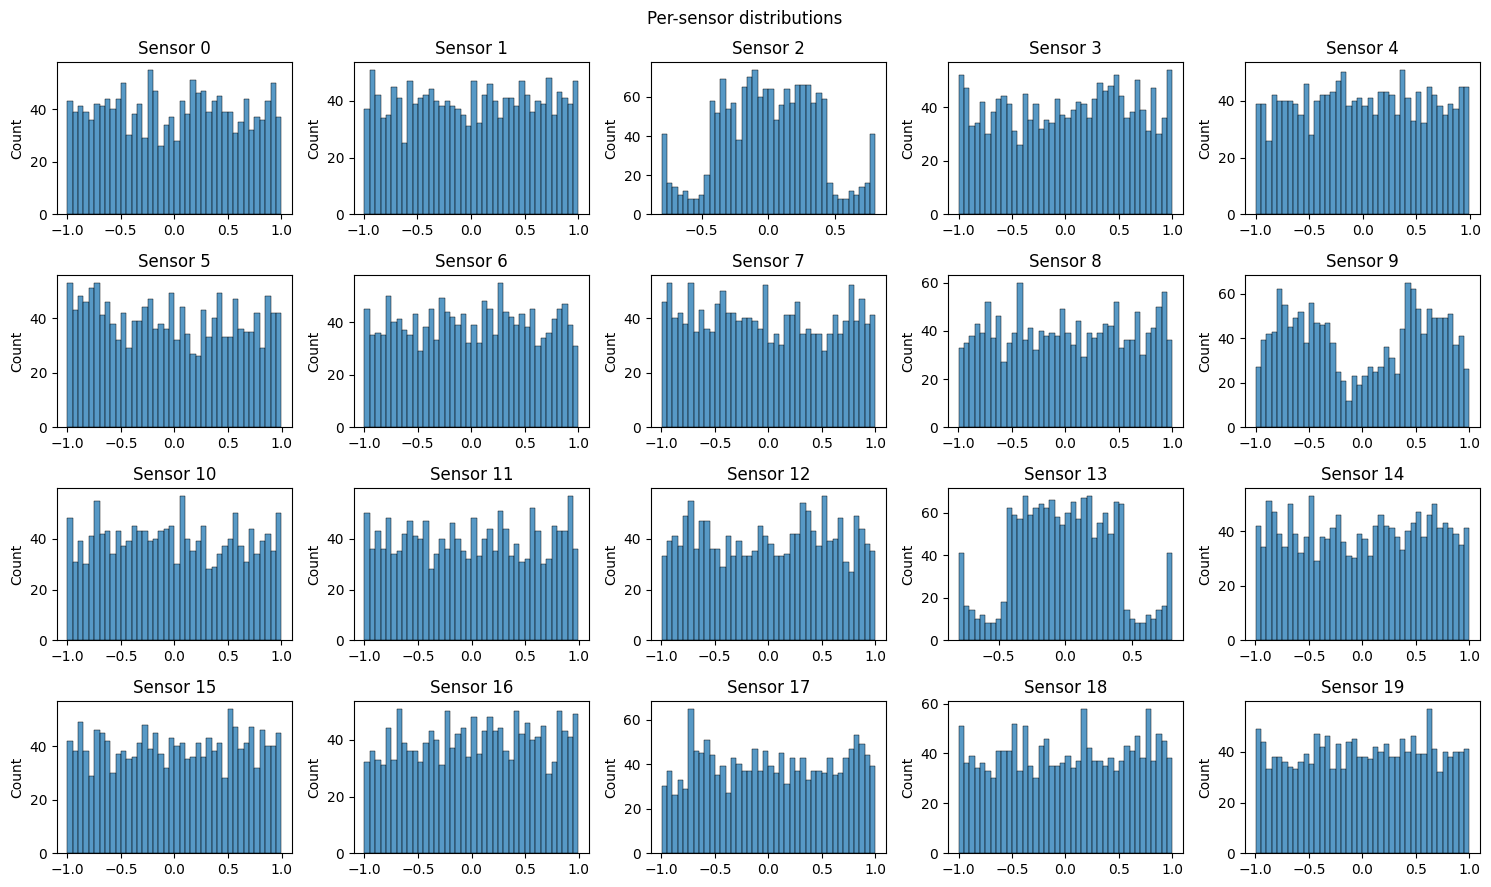

In [3]:
# 2. Per-sensor distributions
fig, axes = plt.subplots(4, 5, figsize=(15, 9))
for i, ax in enumerate(axes.ravel()):
    sns.histplot(df[f"Sensor {i}"], bins=40, ax=ax)
    ax.set_title(f"Sensor {i}")
    ax.set_xlabel("")
fig.suptitle("Per-sensor distributions")
fig.tight_layout()

mean |off-diag corr|: 0.021142618296333206


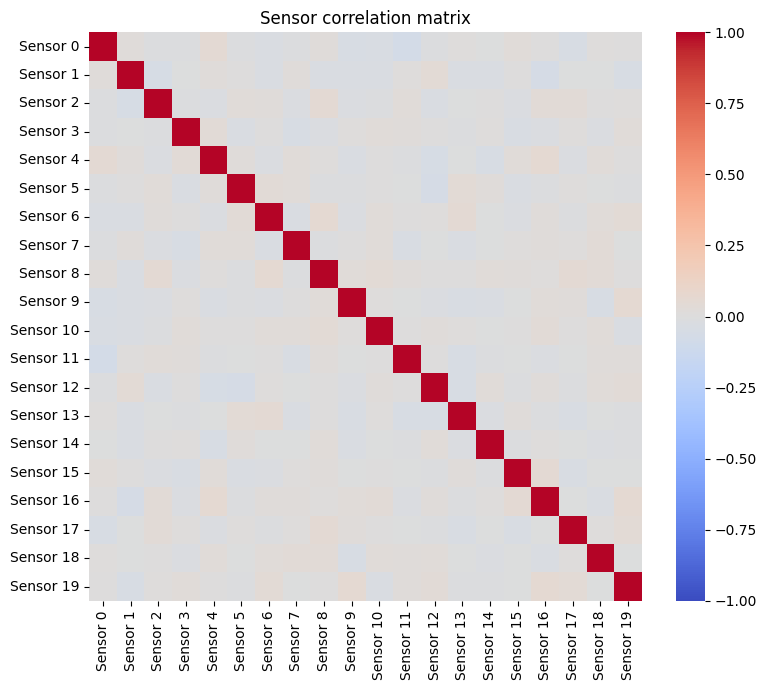

In [4]:
# 3. Inter-sensor correlation matrix
X = df.drop(columns=["Label"])
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Sensor correlation matrix")
fig.tight_layout()
print("mean |off-diag corr|:", np.abs(corr.to_numpy()[~np.eye(len(corr), dtype=bool)]).mean())

Components needed for 95% var: 19


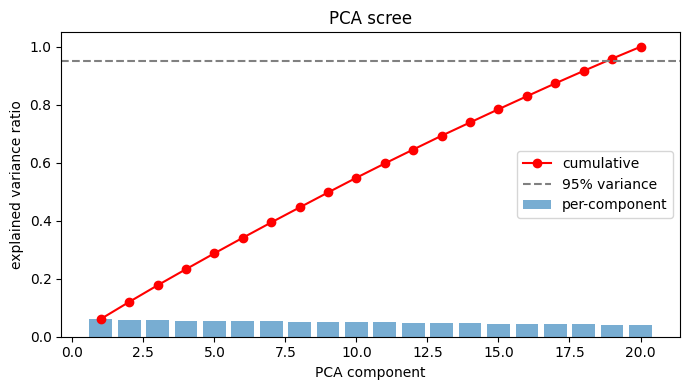

In [5]:
# 4. PCA scree plot
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X)
pca = PCA(svd_solver="full").fit(Xs)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(evr) + 1), evr, alpha=0.6, label="per-component")
ax.plot(range(1, len(cum) + 1), cum, "o-", color="red", label="cumulative")
ax.axhline(0.95, color="grey", linestyle="--", label="95% variance")
ax.set_xlabel("PCA component")
ax.set_ylabel("explained variance ratio")
ax.set_title("PCA scree")
ax.legend()
fig.tight_layout()
print("Components needed for 95% var:", np.searchsorted(cum, 0.95) + 1)

C:\Users\USER\Desktop\challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\Desktop\challenge\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


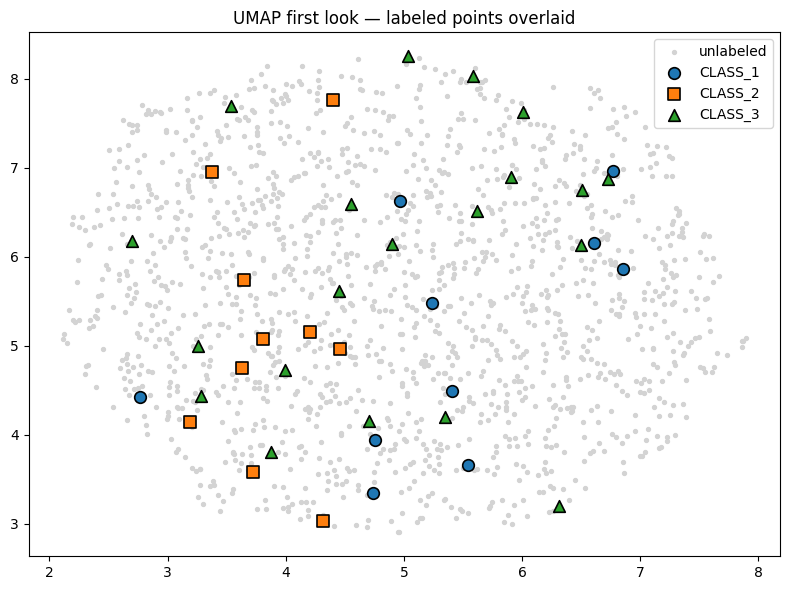

In [6]:
# 5. First-look UMAP
import umap

coords = umap.UMAP(n_components=2, random_state=42).fit_transform(Xs)
y = df["Label"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=8, c="lightgrey", label="unlabeled")
for cls, marker in zip([1.0, 2.0, 3.0], ["o", "s", "^"], strict=True):
    mask = y == cls
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=70,
        marker=marker,
        label=f"CLASS_{int(cls)}",
        edgecolor="black",
        linewidth=1.2,
    )
ax.set_title("UMAP first look — labeled points overlaid")
ax.legend()
fig.tight_layout()